In [4]:
using Plots, JLD2
include("analysis_tools.jl");

In [5]:
# setting up the problem

# parameters
nx=100; ny=100     # number of spatial points
Lx=10.0; Ly=10.0     # length of the domain
Δx=Lx/nx; Δy=Ly/ny    # spatial step
ν=0.1    # viscosity
kx=2*pi/Lx; ky=2*pi/Ly   # wave number for initial condition
u_mean=1 # mean velocity
u_amplitude=0.5 # amplitude of the initial condition

x = range(Δx/2, Lx - Δx/2, length=nx) # cell-centered grid
y = range(Δy/2, Ly - Δy/2, length=ny)

# initial condition
u0(x, y) = u_mean .+ u_amplitude.*cos.(kx*x).*cos.(ky*y)

# added noise strength for stabilizied learning
noise_strength=0.00f0

# time
nt = 10000
t_end=15
Δt = t_end/nt
println("Using Δt = $Δt, nt = $nt")

Using Δt = 0.0015, nt = 10000


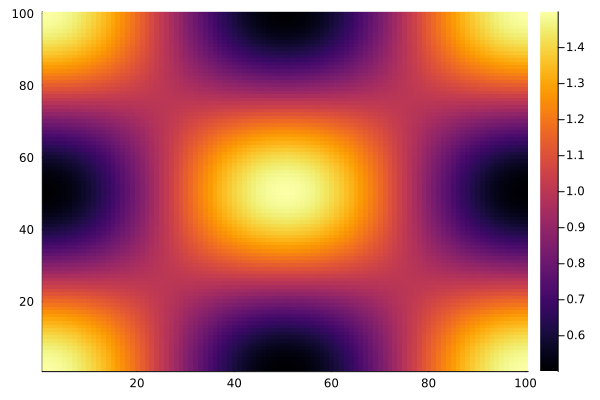

In [6]:
u = zeros(nx, ny)
for (i, x_i) in enumerate(x)
    for (j, y_j) in enumerate(y)
        u[i, j] = u0(x_i, y_j)
    end
end
heatmap(u)